## Cross-Validation

Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

In this notebook, we will optimize hyperparameters with various Cross-Validation Schemes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    LeaveOneOut,
    LeavePOut,
    StratifiedKFold,
    GridSearchCV,
    train_test_split,
)

In [2]:
# if you want more information about the dataset for this demo:

# scikit-learn dataset
# https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

# dataset information: UCI Machine Learning Repository
# https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)
    
# in short, classification problem, trying to predict whether the tumor
# is malignant or benign

# load dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
y = y.map({0:1, 1:0})

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# percentage of benign (0) and malign tumors (1)

y.value_counts() / len(y)

target
0    0.627417
1    0.372583
Name: count, dtype: float64

In [4]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((398, 30), (171, 30))

## K-Fold Cross-Validation

In [5]:
# Logistic Regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=1, l1_ratio=0.0, solver='saga', random_state=4, max_iter=10000
    )),
])

# hyperparameter space
param_grid = dict(
    classifier__l1_ratio=[0.0, 0.5, 1.0],
    classifier__C=[0.1, 1, 10],
)

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=4)

# search
clf = GridSearchCV(
    logit,
    param_grid,
    scoring='accuracy',
    cv=kf,  # k-fold
    refit=True,  # refits best model to entire dataset
)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'classifier__C': 1, 'classifier__l1_ratio': 1.0}

In [6]:
results = pd.DataFrame(
    search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print(results.shape)
results

(9, 3)


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.972373,0.009407
1,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.962342,0.021107
2,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.954810,0.018804
3,"{'classifier__C': 1, 'classifier__l1_ratio': 0.0}",0.979968,0.012729
4,"{'classifier__C': 1, 'classifier__l1_ratio': 0.5}",0.977468,0.014556
5,"{'classifier__C': 1, 'classifier__l1_ratio': 1.0}",0.979968,0.012729
6,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.974937,0.013694
7,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.974937,0.013694
8,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.967405,0.012661


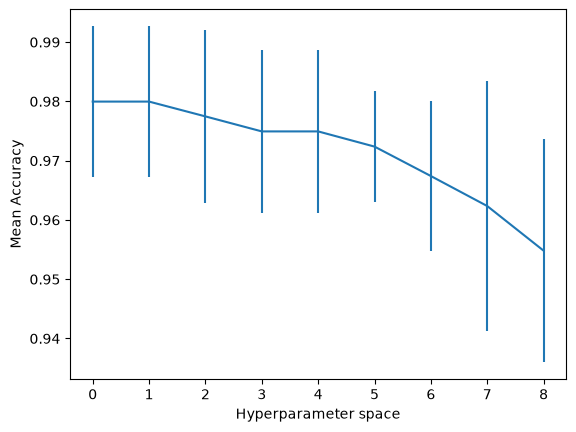

In [7]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_test_score'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean Accuracy')

plt.xlabel('Hyperparameter space')
plt.show()

In [8]:
# let's get the predictions
train_preds = search.predict(X_train)
test_preds = search.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, train_preds))
print('Test Accuracy: ', accuracy_score(y_test, test_preds))

Train Accuracy:  0.9874371859296482
Test Accuracy:  0.9649122807017544


## Repeated K-Fold

In [9]:
# Logistic Regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=1, l1_ratio=0.0, solver='saga', random_state=4, max_iter=10000
    )),
])

# hyperparameter space
param_grid = dict(
    classifier__l1_ratio=[0.0, 0.5, 1.0],
    classifier__C=[0.1, 1, 10],
)

# Repeated K-Fold Cross-Validation
rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=4,
)

# search
clf = GridSearchCV(
    logit,
    param_grid,
    scoring='accuracy',
    cv=rkf,  # repeated k-fold
    refit=True,  # refits best model to entire dataset
)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'classifier__C': 1, 'classifier__l1_ratio': 0.5}

In [10]:
results = pd.DataFrame(
    search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print(results.shape)

results

(9, 3)


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.973851,0.018850
1,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.966326,0.021134
2,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.959794,0.020579
3,"{'classifier__C': 1, 'classifier__l1_ratio': 0.0}",0.978889,0.016781
4,"{'classifier__C': 1, 'classifier__l1_ratio': 0.5}",0.979902,0.017802
5,"{'classifier__C': 1, 'classifier__l1_ratio': 1.0}",0.975633,0.018030
6,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.973358,0.014827
7,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.972861,0.014971
8,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.966839,0.017195


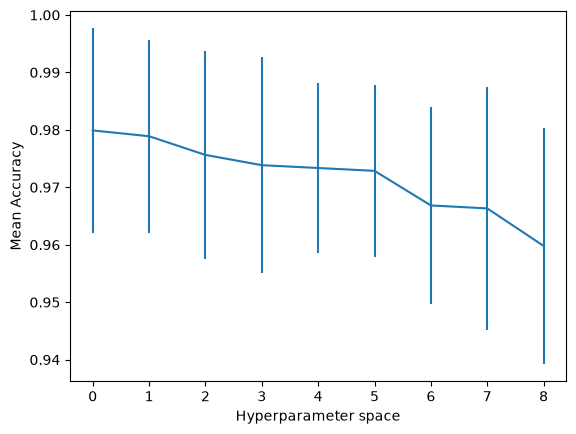

In [11]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_test_score'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean Accuracy')

plt.xlabel('Hyperparameter space')
plt.show()

In [12]:
# let's get the predictions
train_preds = search.predict(X_train)
test_preds = search.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, train_preds))
print('Test Accuracy: ', accuracy_score(y_test, test_preds))

Train Accuracy:  0.9899497487437185
Test Accuracy:  0.9766081871345029


## Leave One Out

Leave-one-out cross-validation can be computationally expensive and produce high-variance estimates, so it is mainly included here for demonstration.

In [13]:
# Logistic Regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=1, l1_ratio=0.0, solver='saga', random_state=4, max_iter=10000
    )),
])

# hyperparameter space
param_grid = dict(
    classifier__l1_ratio=[0.0, 0.5, 1.0],
    classifier__C=[0.1, 1, 10],
)

# Leave One Out Cross-Validation
loo = LeaveOneOut()

# search
clf = GridSearchCV(
    logit,
    param_grid,
    scoring='accuracy',
    cv=loo,  # LOOCV
    refit=True,  # refits best model to entire dataset
)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'classifier__C': 1, 'classifier__l1_ratio': 0.0}

In [14]:
results = pd.DataFrame(
    search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print(results.shape)

results.head()

(9, 3)


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.977387,0.148666
1,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.972362,0.163934
2,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.959799,0.196430
3,"{'classifier__C': 1, 'classifier__l1_ratio': 0.0}",0.982412,0.131448
4,"{'classifier__C': 1, 'classifier__l1_ratio': 0.5}",0.979899,0.140344


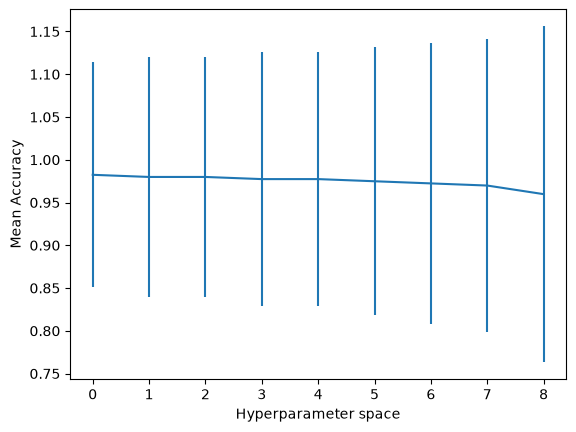

In [15]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_test_score'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean Accuracy')

plt.xlabel('Hyperparameter space')
plt.show()

In [16]:
# let's get the predictions
train_preds = search.predict(X_train)
test_preds = search.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, train_preds))
print('Test Accuracy: ', accuracy_score(y_test, test_preds))

Train Accuracy:  0.9899497487437185
Test Accuracy:  0.9766081871345029


## Leave P Out

Leave-P-out cross-validation evaluates every possible set of `p` held-out observations. Its cost grows combinatorially, so it is rarely practical beyond small datasets.

In [17]:
# Logistic Regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=1, l1_ratio=0.0, solver='saga', random_state=4, max_iter=10000
    )),
])

# hyperparameter space
param_grid = dict(
    classifier__l1_ratio=[0.0, 0.5, 1.0],
    classifier__C=[0.1, 1, 10],
)

# Leave P Out Cross-Validation
lpo = LeavePOut(p=2)

# I take a smaller sample of the data, otherwise
# my computer runs out of memory
X_train_small = X_train.head(30)
y_train_small = y_train.head(30)

# search
clf = GridSearchCV(
    logit,
    param_grid,
    scoring='accuracy',
    cv=lpo,  # LPOCV
    refit=True,  # refits best model to entire dataset
)

search = clf.fit(X_train_small, y_train_small)

# best hyperparameters
search.best_params_

{'classifier__C': 10, 'classifier__l1_ratio': 0.0}

In [18]:
results = pd.DataFrame(
    search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print(results.shape)

results.head()

(9, 3)


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.910345,0.209012
1,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.831034,0.264058
2,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.666667,0.327536
3,"{'classifier__C': 1, 'classifier__l1_ratio': 0.0}",0.932184,0.177786
4,"{'classifier__C': 1, 'classifier__l1_ratio': 0.5}",0.897701,0.210078


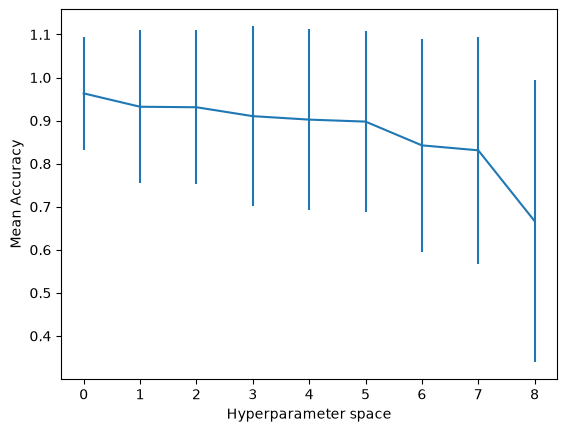

In [19]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_test_score'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean Accuracy')

plt.xlabel('Hyperparameter space')
plt.show()

In [20]:
# let's get the predictions
train_preds = search.predict(X_train)
test_preds = search.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, train_preds))
print('Test Accuracy: ', accuracy_score(y_test, test_preds))

Train Accuracy:  0.964824120603015
Test Accuracy:  0.9415204678362573


## Stratified K-Fold Cross-Validation

In [21]:
# Logistic Regression
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=1, l1_ratio=0.0, solver='saga', random_state=4, max_iter=10000
    )),
])

# hyperparameter space
param_grid = dict(
    classifier__l1_ratio=[0.0, 0.5, 1.0],
    classifier__C=[0.1, 1, 10],
)

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

# search
clf = GridSearchCV(
    logit,
    param_grid,
    scoring='accuracy',
    cv=skf,  # stratified k-fold
    refit=True,  # refits best model to entire dataset
)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'classifier__C': 1, 'classifier__l1_ratio': 0.0}

In [22]:
results = pd.DataFrame(
    search.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print(results.shape)

results.head()

(9, 3)


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.969842,0.020409
1,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.967373,0.023281
2,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.959747,0.027055
3,"{'classifier__C': 1, 'classifier__l1_ratio': 0.0}",0.974873,0.011252
4,"{'classifier__C': 1, 'classifier__l1_ratio': 0.5}",0.974842,0.013781


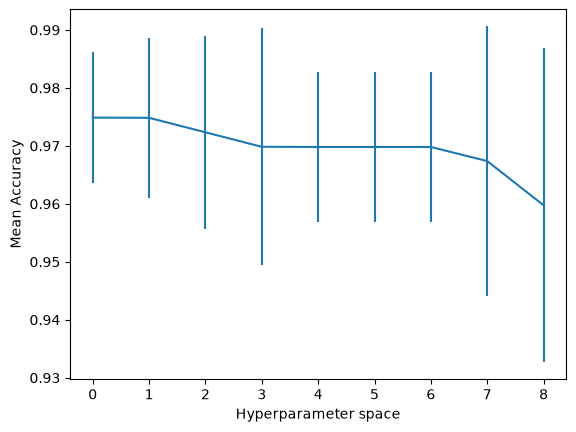

In [23]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_test_score'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean Accuracy')

plt.xlabel('Hyperparameter space')
plt.show()

In [24]:
# let's get the predictions
train_preds = search.predict(X_train)
test_preds = search.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, train_preds))
print('Test Accuracy: ', accuracy_score(y_test, test_preds))

Train Accuracy:  0.9899497487437185
Test Accuracy:  0.9766081871345029
